## 2D Resolution Estimation: FRC vs DCR

This notebook demonstrates 2D image resolution estimation using two complementary methods:

- **FRC** (Fourier Ring Correlation) — correlation-based, uses checkerboard splitting of a single image
- **DCR** (Decorrelation Analysis) — single-image, parameter-free

We compare results on three real super-resolution microscopy datasets from the original FRC and DCR papers.

**References:**
- Koho et al. (2019) "Fourier ring correlation simplifies image restoration in fluorescence microscopy", *Nature Communications* 10:3103.
- Descloux et al. (2019) "Parameter-free image resolution estimation based on decorrelation analysis", *Nature Methods* 16:918-924.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

from cubic.cuda import CUDAManager, ascupy, asnumpy
from cubic.metrics.spectral.dcr import dcr_curve
from cubic.metrics.spectral.frc import calculate_frc

USE_GPU = CUDAManager().num_gpus > 0
print(f"GPU available: {USE_GPU}")

GPU available: True


In [2]:
from pathlib import Path

import pooch

DATA_DIR = Path("../data")


def fetch_data(filename, url, known_hash):
    """Download file to DATA_DIR if not already present."""
    return pooch.retrieve(
        url=url,
        known_hash=f"sha256:{known_hash}",
        fname=filename,
        path=DATA_DIR,
    )


# Tubulin STED (Koho et al. 2019, figshare)
fetch_data(
    "Tubulin_057nm.tif",
    "https://ndownloader.figshare.com/files/15202592",
    "b14958909c605e61b1e77a6239c29b795a657d4fd175ae7edf438202fe83455a",
)

# Vimentin STED (Koho et al. 2019, figshare)
fetch_data(
    "Vimentin_029nm.tif",
    "https://ndownloader.figshare.com/files/15202565",
    "d22bed0e4c193884d25761a63ebf1ec17e4b8f5490da33409e568c0d3844a55a",
)

# COS7 STED (Descloux et al. 2019, ImDecorr GitHub — saved as test_image.tif upstream)
fetch_data(
    "demo_COS7_a-tub_abberior_star635_confocal_STED.tif",
    "https://github.com/Ades91/ImDecorr/raw/refs/heads/master/test_image.tif",
    "74d4ce76e67a5dd376655fff74231e026893198bd92458ab660c3fddb7c8288f",
)

'/hpc/mydata/alex.kalinin/cubic/examples/data/demo_COS7_a-tub_abberior_star635_confocal_STED.tif'

In [3]:
from cubic.metrics.spectral.plot import plot_frc_curve, plot_dcr_curves


def measure_and_plot(image, spacing, title):
    """Compute FRC + DCR resolution and plot both curves."""
    frc_data = calculate_frc(image, spacing=spacing, curve_fit_type="smooth-spline")
    frc_res = frc_data.resolution["resolution"]

    dcr_res, dcr_radii, dcr_curves, dcr_peaks = dcr_curve(image, spacing=spacing)

    print(f"FRC resolution: {frc_res * 1000:.1f} nm")
    print(f"DCR resolution: {dcr_res * 1000:.1f} nm")

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    plot_frc_curve(frc_data, axes[0])
    plot_dcr_curves(dcr_radii, dcr_curves, dcr_peaks, axes[1])
    axes[1].set_title(f"DCR — {dcr_res * 1000:.1f} nm")
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return frc_res, dcr_res

### Dataset 1 — Tubulin STED (Koho et al. 2019, Figure 3)

Fixed cell with microtubule cytoskeleton stained with Star635, imaged on an
Abberior Instruments Expert Line STED system: 633 nm excitation, 100x/1.4
(UPLSAPO100XO) objective. Part of a pixel-size gradient series (29–113 nm);
this image uses 56.5 nm pixels.
Source: Koho et al. (2019) *Nat. Commun.* 10:3103,
[figshare dataset](https://doi.org/10.6084/m9.figshare.8158934.v1).

Raw shape: (708, 708, 3), dtype: uint8
Image shape: (708, 708)
Pixel size: 56.5 nm


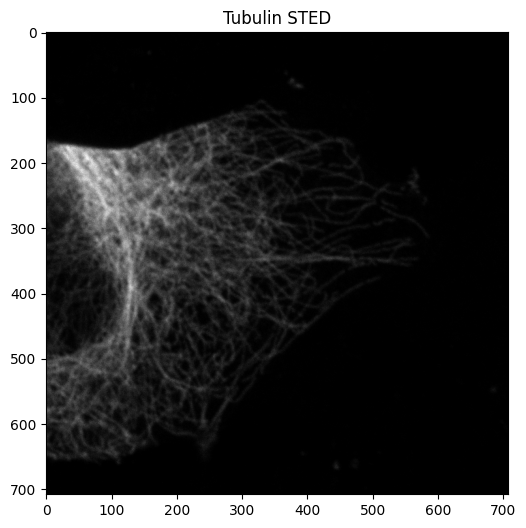

In [4]:
tubulin_rgb = io.imread("../data/Tubulin_057nm.tif")
print(f"Raw shape: {tubulin_rgb.shape}, dtype: {tubulin_rgb.dtype}")

# Convert RGB to grayscale float32
tubulin = color.rgb2gray(tubulin_rgb).astype(np.float32)
tubulin_spacing = 0.0565  # µm

# Move to GPU if available
if USE_GPU:
    tubulin = ascupy(tubulin)

print(f"Image shape: {tubulin.shape}")
print(f"Pixel size: {tubulin_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(asnumpy(tubulin), cmap="gray")
ax.set_title("Tubulin STED")
plt.show()

FRC resolution: 287.8 nm
DCR resolution: 326.2 nm


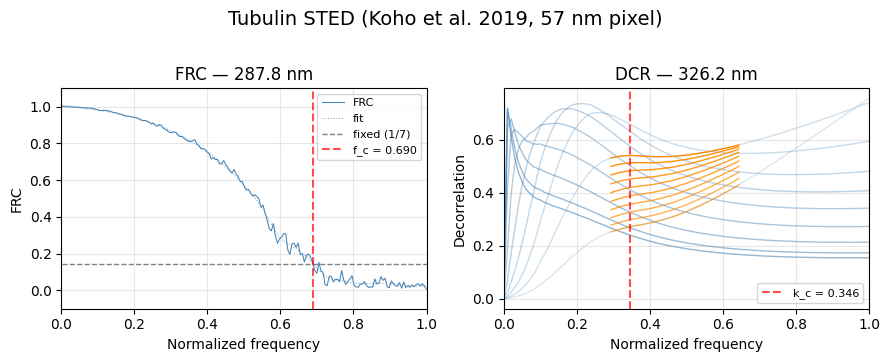

In [5]:
tubulin_frc_res, tubulin_dcr_res = measure_and_plot(
    tubulin,
    tubulin_spacing,
    "Tubulin STED (Koho et al. 2019, 57 nm pixel)",
)

### Dataset 2 — Vimentin STED (Koho et al. 2019)

Fixed cell with intermediate filaments (vimentin) cytoskeleton stained with
Star635, imaged on an Abberior Instruments Expert Line STED system: 633 nm
excitation, 100x/1.4 (UPLSAPO100XO) objective. Part of the same pixel-size
gradient series as Dataset 1 (29–113 nm); this image uses 29 nm pixels.
Source: Koho et al. (2019) *Nat. Commun.* 10:3103,
[figshare dataset](https://doi.org/10.6084/m9.figshare.8158934.v1).

Raw shape: (1389, 1389, 3), dtype: uint8
Image shape: (1389, 1389)
Pixel size: 29.0 nm


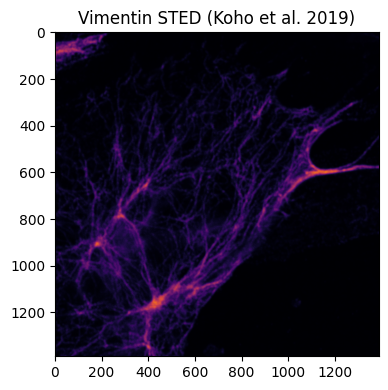

In [6]:
vimentin_rgb = io.imread("../data/Vimentin_029nm.tif")
print(f"Raw shape: {vimentin_rgb.shape}, dtype: {vimentin_rgb.dtype}")

# Convert RGB to grayscale float32
vimentin = color.rgb2gray(vimentin_rgb).astype(np.float32)
vimentin_spacing = 0.029  # µm

# Move to GPU if available
if USE_GPU:
    vimentin = ascupy(vimentin)

print(f"Image shape: {vimentin.shape}")
print(f"Pixel size: {vimentin_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(asnumpy(vimentin), cmap="inferno")
ax.set_title("Vimentin STED (Koho et al. 2019)")
plt.tight_layout()
plt.show()

FRC resolution: 238.3 nm
DCR resolution: 286.8 nm


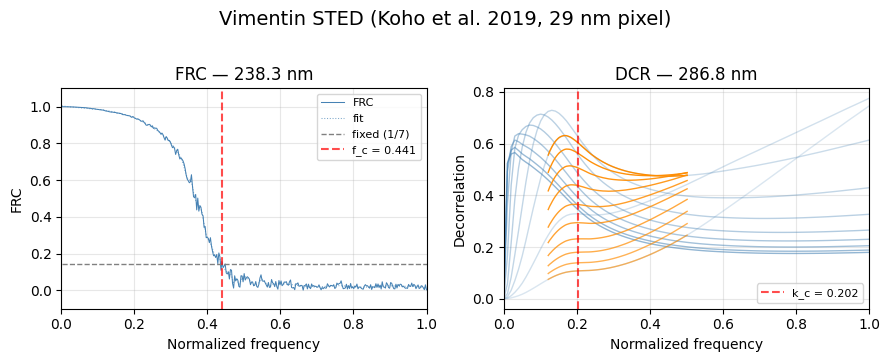

In [7]:
vimentin_frc_res, vimentin_dcr_res = measure_and_plot(
    vimentin,
    vimentin_spacing,
    "Vimentin STED (Koho et al. 2019, 29 nm pixel)",
)

### Dataset 3 — COS7 STED (Descloux et al. 2019, Figure 2c)

STED image of alpha-tubulin in COS7 cells labeled with Abberior STAR 635P.
Acquired on a Leica TCS SP8 STED 3X with HC PL APO CS2 100x/1.40 OIL objective:
634 nm excitation (11.2 µW), 775 nm STED depletion (201.5 mW), HyD detector
(645–720 nm, gain 100), pixel size 15 nm binned 2x, 8x frame average, 200 Hz,
time gate 1–11 ns, Mowiol-DABCO mounting.
Source: Descloux et al. (2019) *Nat. Methods* 16:918-924, Supplementary Table 1.

Raw shape: (510, 510), dtype: uint8
Image shape: (510, 510)
Pixel size: 15.3 nm


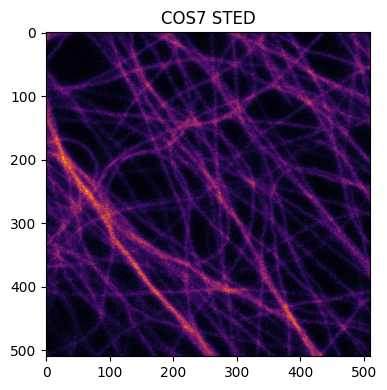

In [8]:
sted = io.imread("../data/demo_COS7_a-tub_abberior_star635_confocal_STED.tif")
print(f"Raw shape: {sted.shape}, dtype: {sted.dtype}")

sted = sted.astype(np.float32)
sted_spacing = 0.0153  # µm

# Move to GPU if available
if USE_GPU:
    sted = ascupy(sted)

print(f"Image shape: {sted.shape}")
print(f"Pixel size: {sted_spacing * 1000:.1f} nm")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(asnumpy(sted), cmap="inferno")
ax.set_title("COS7 STED")
plt.tight_layout()
plt.show()

FRC resolution: 101.8 nm
DCR resolution: 111.0 nm


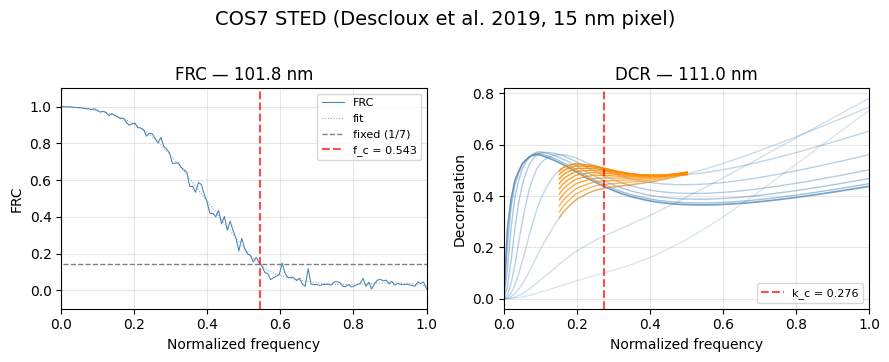

In [9]:
sted_frc_res, sted_dcr_res = measure_and_plot(
    sted,
    sted_spacing,
    "COS7 STED (Descloux et al. 2019, 15 nm pixel)",
)